## Auto-regressive Language Models:
An auto-regressive language model is a model that **predicts the next token based on all previously generated tokens. its current output depends on its own previous outputs**

or,
An autoregressive language model predicts the next token using previously available tokens in the sequence. During generation, previously generated tokens become part of the context for predicting the next token.

Suppose a sentence contains tokens or context(collection of tokens): $x_1, x_2, x_3, \dots, x_T$.

The model computes the probability of the next token:

$$
P(x_t \mid x_1, x_2, \dots, x_{t-1})
$$

The probability of an entire sentence is factorized as a product of
conditional probabilities (the **chain rule of probability**):

$$
P(x_1, x_2, \dots, x_T) = P(x_1) \, P(x_2 \mid x_1) \, P(x_3 \mid x_1, x_2) \cdots P(x_T \mid x_1, \dots, x_{T-1})
$$

or more compactly:

$$
P(x_1, \dots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, \dots, x_{t-1})
$$

${x_t}$ = **next token**,
$x_{t-1}$ = **previous token**, 
t = **current token position**,
T = **total number of tokens**

#### Example

Given the sentence: **"I love machine learning"**

$$
P(\text{I}) \times P(\text{love} \mid \text{I}) \times P(\text{machine} \mid \text{I}, \text{love}) \times P(\text{learning} \mid \text{I}, \text{love}, \text{machine})
$$


**The context is the collection of tokens that the model can use as information when making a prediction.**  

Context = [I, love, machine]


<img src="./images/language_model_taxonomy.png" alt="Language Model Family Tree" width="1400">


> **Note:** BERT is not an autoregressive language model; it uses **Masked Language Modeling (MLM)**.
>
> - **T5 is not exclusively an autoregressive language model:** the **encoder** uses bidirectional self-attention for understanding the input, while the **decoder** performs autoregressive generation.

### Statistical Language Models

A language model answers one question: **"What is the probability of this word sequence?"**

p($x_1, x_2, x_3, \dots, x_T$)

By the chain rule of probability:


$$
P(x_1, x_2, \dots, x_T) = P(x_1) \, P(x_2 \mid x_1) \, P(x_3 \mid x_1, x_2) \cdots P(x_T \mid x_1, \dots, x_{T-1})
$$

**Problem:** P(next word | entire past history)
To predict the next word using the exact full history, the model would need to have seen that exact same sentence before but since sentences can be almost infinitely long and varied, the exact same long sentence almost never repeats in the training data. So there's no way to "look up" the right probability from experience.

**Solution: the Markov Assumption**

Approximate the whole history using only the last few words, instead of the entire past. How many words you keep (n) defines the model. this is what gives us n-gram models (bigram, trigram, etc.)


**N-gram Models as Markov Chains:**

| Model       | Markov Order | Conditioned On                                   |
|-------------|:------------:|--------------------------------------------------|
| **Unigram** | 0            | $P(x_t)$ nothing                               |
| **Bigram**  | 1            | $P(x_t \mid x_{t-1})$                            |
| **Trigram** | 2            | $P(x_t \mid x_{t-2}, x_{t-1})$                   |
| **N-gram**  | N-1          | $P(x_t \mid x_{t-N+1}, \dots, x_{t-1})$          |


### Evaluating Language Models (Statistical, Neural, and Transformer-based)

When we train a language model, we want to know how well it predicts text. We evaluate a language model by measuring the probabilities it assigns to the tokens in a dataset, such as the training set or a held-out test set.

Two widely used evaluation metrics in language modeling are:
* Log-Likelihood
* Per-Word Log-Likelihood (WLL)
* Perplexity

##### 1. Log-Likelihood
The probability of a sequence is obtained by multiplying many conditional probabilities. Since these probabilities are often very small (e.g., \(0.0001\)), multiplying many numbers less than 1 can produce an extremely small value that may underflow toward zero.

Using logarithms converts multiplication into addition:

$$ \log(ab) = \log a + \log b $$

For a test set containing multiple sequences, the total log-likelihood is:

$$ LL(X_{\text{test}}) = \sum_{X \in X_{\text{test}}} \log P(X) $$

#### 2. Per-Word Log-Likelihood (WLL)

The total Log-Likelihood depends on the size of the dataset. A longer test set contains more tokens, so its total log-likelihood will naturally be different from that of a shorter test set.

To make the value more comparable, we calculate the average log-likelihood per token (word).

If the test set contains a total of \(N\) tokens, then:

$$ { WLL(X_{\text{test}}) = \frac{LL(X_{\text{test}})}{N} } $$

Using the definition of Log-Likelihood:

$$ { WLL(X_{\text{test}}) = \frac{ \displaystyle \sum_{X\in X_{\text{test}}} \log P(X) }{ \displaystyle \sum_{X\in X_{\text{test}}}|X| } } $$

where:
- $X_{\text{test}}$ = the test set
- $X$ = an individual sequence in the test set
- $P(X)$ = probability assigned to sequence $X$
- $|X|$ = number of tokens in sequence $X$
- $\sum_{X \in X_{\text{test}}} |X|$ = total number of tokens in the test set


##### 3. Perplexity (PPL)

Perplexity is the most commonly reported metric for language models. It is defined as the exponentiation of the negative average log-likelihood per token:

$$ \text{PPL}(X_{\text{test}}) = \exp\left( -\text{WLL}(X_{\text{test}}) \right) $$

Expanding:

$$ \text{PPL}(X_{\text{test}}) = \exp\left( -\frac{1}{N} \sum_{X \in X_{\text{test}}} \log P(X) \right) $$

**Interpretation:** Perplexity can be interpreted as "the effective number of equally-likely choices" under the model. A lower perplexity indicates that the model is less surprised by the test data and thus predicts it better. A perfect model would assign probability 1 to each token, giving a perplexity of 1.


#### Example:
> "When a dog sees a squirrel it will usually ___"

Suppose we treat each candidate token as a single-token "sequence" ($|X| = 1$) and look at the probability the model assigns to it:

| Token | $P(X)$ | $\log P(X)$ (LL) | $WLL = LL / N$ | $PPL = \exp(-WLL)$ |
|---|---|---|---|---|
| "be"    | 0.0352 | $\ln(0.0352) \approx -3.35$ | $-3.35$ | $28.4$ |
| "jump"  | 0.0338 | $\ln(0.0338) \approx -3.39$ | $-3.39$ | $29.6$ |
| "start" | 0.0289 | $\ln(0.0289) \approx -3.54$ | $-3.54$ | $34.6$ |
| "run"   | 0.0277 | $\ln(0.0277) \approx -3.59$ | $-3.59$ | $36.1$ |
| "try"   | 0.0219 | $\ln(0.0219) \approx -3.82$ | $-3.82$ | $45.7$ |

**Walking through "be" as an example:**

1. **Log-Likelihood:** $LL = \log P(\text{"be"}) = \log(0.0352) \approx -3.35$
2. **Per-Word Log-Likelihood:** Since this is a single token ($N = 1$), $WLL = LL / N = -3.35$
3. **Perplexity:** $PPL = \exp(-WLL) = \exp(3.35) \approx 28.4$ 

> As probability decreases (from "be" at $0.0352$ down to "try" at $0.0219$), log-likelihood becomes more negative, and perplexity increases - confirming the inverse relationship between probability and perplexity. The token "be" is the model's most confident (least surprised) prediction, with the lowest perplexity.


**Note:** Traditional language models can be evaluated using likelihood-based metrics such as Log-Likelihood, NLL, and Perplexity. Modern LLMs are typically evaluated using a broad suite of task-specific benchmarks and human/automated evaluations covering capabilities such as knowledge(MMLU, GPQA), reasoning(ARC-AGI, GPQA), mathematics(AIME), coding(SWE-Bench), instruction following, safety, and real-world task performance.

### 1. Unigram Language Model

The probability of a token does **not** depend on any other previous token. It assumes that **every token in a sequence is drawn independently**, no context at all.

$$P(x_1, x_2, \dots, x_n) = P(x_1) \times P(x_2) \times \dots \times P(x_t)$$

or

$$
P(x_1, x_2, \dots, x_T) = \prod_{t=1}^{T} P(x_t)
$$

It only cares about how frequently a word appears in a given text.

### Example of Unigram Language Model
Imagine we have a very small dataset (corpus) consisting of just two sentences:
1. "the cat sat on the mat"
2. "the dog sat on the log"

##### step 1: tokenized the text and Count token frequencies
We split the sentences into individual tokens and count how many times each token appears in our entire corpus.
* the: 4
* cat: 1
* sat: 2
* on: 2
* mat: 1
* dog: 1
* log: 1

**Total words in corpus: 12**

##### Step 2: Compute unigram probabilities
The probability of a word **P(x)** is simply its count divided by the total number of tokens in the corpus.
$$P(x) = \frac{\text{count}(x)}{\text{total words}}$$
* P(the) = 4/12 = 0.333

* P(cat) = 1/12 = 0.083 

* P(sat) = 2/12 = 0.166 

* P(on) = 2/12 = 0.166 

* P(mat) = 1/12 = 0.083 

* P(dog) = 1/12 = 0.083 

* P(log) = 1/12 = 0.083 


##### Step 4: Testing the Model
take a new sentence and multiply together the probabilities of its tokens, using the numbers learned during training. if the word(token) is out of training then the probability is zero.

##### Test Sentence 1: "the cat sat" *(seen in training)*
$$P = P(\text{the}) \times P(\text{cat}) \times P(\text{sat})$$
$$= 0.333 \times 0.083 \times 0.166 \approx 0.0046$$

##### Test Sentence 2: "the the on" *(new order, known words)*
$$P = P(\text{the}) \times P(\text{the}) \times P(\text{on})$$
$$= 0.333 \times 0.333 \times 0.166 \approx 0.0184$$

> ⚠️ **Even though this sentence is nonsense grammatically**, the unigram model still gives it a decent score, it ignores word order entirely. This is the model's key weakness.  
> *(Notice it actually scores this nonsense higher than the correct sentence because "the" is so common!)*

##### Test Sentence 3: "the cat robot" *(unseen word)*
$$P = P(\text{the}) \times P(\text{cat}) \times P(\text{robot})$$
$$= 0.333 \times 0.083 \times 0 = 0$$

> ⚠️ **Zero-probability problem**: any unseen word makes the entire sentence probability zero, even if every other word is common. 

In [1]:
############################################
# Cell 1: Unigram Model from Scratch
############################################
from collections import Counter
import math

# ---------- 1. Training corpus ----------
sentences = [
    "the cat sat on the mat",
    "the dog sat on the log",
]
tokens = (" ".join(sentences)).lower().split()         # flatten corpus into a list of tokens
print(f"Training corpus: {sentences}\nTokens: {tokens}")

# ---------- 2. Count token frequencies ----------
unigrams = Counter(tokens)                              # count each word  # Counter() is a dict subclass that maps each unique word to its frequency
vocab    = list(unigrams.keys())                        # unique vocabulary
V        = len(vocab)                                   # vocab size
N        = sum(unigrams.values())                       # total number of tokens
w2i      = {w: i for i, w in enumerate(vocab)}          # word -> index
i2w      = {i: w for w, i in w2i.items()}               # index -> word

print(f"token frequencies: {unigrams}\nVocab: {vocab}\nTotal tokens N = {N}\nvocab size = {V}\nword to index mapping: {w2i}\nindex to word mapping: {i2w}")

# ---------- 3. Estimate unigram probabilities P(x) = count(x) / N ----------
#create a new dictionary called probs where the keys are words and the values are their calculated probabilities p =c/N (e.g., {"the": 0.333, "cat": 0.083, ...}).
probs = {w: c / N for w, c in unigrams.items()}           # w represents the word (e.g., "the"), c represents the count of that word (e.g., 4), N is the total number of tokens in the corpus (calculated in step 2 as 12).
print(f"Learned probabilities: {probs}")

# ---------- 4. Display the learned unigram probabilities ----------
print("\nLearned probabilities:")
for w, p in probs.items():
    c = unigrams[w]                                     # count for *this* word
    print(f"P({w:<5}) = {c}/{N} = {p:.4f}")

# ---------- 4. Sentence log-probability ----------
# Multiplying many probabilities (each less than 1) together makes the result tend
# toward zero, even for a correct/likely sentence, once it gets long enough �?the
# probability becomes extremely small. To fix this, we take the log of both sides.
# Since log(a x b) = log(a) + log(b), the product turns into a sum:
# log P(x1, ..., xT) = sum( log P(xt) )
def sentence_logprob(sentence, probs):
    log_p = 0.0   # initialize log probability 0
    for w in sentence.split():        # w is each word of the test sentence
        p = probs.get(w, 0.0)         #  # returns 0.0 if `w` isn't in the dictionary (i.e., an unseen word)
        if p == 0.0:
            return float("-inf")      # math.log(0) is undefined and crashes Python, so we manually return -inf to represent it
        log_p += math.log(p)          # # update log_p
    return log_p

# ---------- 5. Test the model ----------
test_sentences = [
    "the cat sat",         # seen words, sensible order
    "the the on",          # known words, nonsense order
    "the cat robot",       # contains an unseen word
]

print("\nTest sentences:")
for s in test_sentences:
    lp = sentence_logprob(s, probs)
    print(f"  log P({s!r:<20}) = {lp:.4f}   (P = {math.exp(lp) if lp != float('-inf') else 0:.6f})")

Training corpus: ['the cat sat on the mat', 'the dog sat on the log']
Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'the', 'dog', 'sat', 'on', 'the', 'log']
token frequencies: Counter({'the': 4, 'sat': 2, 'on': 2, 'cat': 1, 'mat': 1, 'dog': 1, 'log': 1})
Vocab: ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'log']
Total tokens N = 12
vocab size = 7
word to index mapping: {'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4, 'dog': 5, 'log': 6}
index to word mapping: {0: 'the', 1: 'cat', 2: 'sat', 3: 'on', 4: 'mat', 5: 'dog', 6: 'log'}
Learned probabilities: {'the': 0.3333333333333333, 'cat': 0.08333333333333333, 'sat': 0.16666666666666666, 'on': 0.16666666666666666, 'mat': 0.08333333333333333, 'dog': 0.08333333333333333, 'log': 0.08333333333333333}

Learned probabilities:
P(the  ) = 4/12 = 0.3333
P(cat  ) = 1/12 = 0.0833
P(sat  ) = 2/12 = 0.1667
P(on   ) = 2/12 = 0.1667
P(mat  ) = 1/12 = 0.0833
P(dog  ) = 1/12 = 0.0833
P(log  ) = 1/12 = 0.0833

Test sentences:
  log P('the cat sat'       ) 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter

# ---------- Data ----------
sentences = [
    "the cat sat on the mat",
    "the dog sat on the log",
]

tokens = (" ".join(sentences)).lower().split()
unigrams = Counter(tokens)
vocab = list(unigrams.keys())
V = len(vocab)
w2i = {w: i for i, w in enumerate(vocab)}

# Convert tokens to indices
corpus = torch.tensor([w2i[w] for w in tokens], dtype=torch.long)

# ---------- Model (Correct) ----------
class UnigramModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # Learnable logits for each word (THIS IS THE DISTRIBUTION)
        self.logits = nn.Parameter(torch.zeros(vocab_size))

    def forward(self):
        # Returns log probabilities for numerical stability
        return F.log_softmax(self.logits, dim=0)

    def probs(self):
        # Returns probabilities (for inference)
        return F.softmax(self.logits, dim=0)

model = UnigramModel(V)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# ---------- Training ----------
for epoch in range(200):
    optimizer.zero_grad()

    # Get log probabilities for all words
    log_probs = model()                          # shape: (V,)

    # Look up log probs for training tokens
    token_log_probs = log_probs[corpus]          # shape: (N,)

    # Negative log likelihood loss
    loss = -token_log_probs.mean()

    loss.backward()
    optimizer.step()

# ---------- Results ----------
with torch.no_grad():
    learned_probs = model.probs()

    # Compare with counting-based probabilities
    N = len(tokens)
    print("Learned vs Empirical probabilities:")
    for word in vocab:
        idx = w2i[word]
        learned = learned_probs[idx].item()
        empirical = unigrams[word] / N
        print(f"  P({word:5s}) = {learned:.4f} (learned) vs {empirical:.4f} (empirical)")

# ---------- Sentence log-probability ----------
def sentence_logprob_torch(sentence, learned, w2i):
    words = sentence.split()
    ids   = [w2i[w] for w in words if w in w2i]   # skip unseen words
    if len(ids) != len(words):                    # any unseen word-zero prob
        return float("-inf")
    return float(torch.log(learned[ids]).sum())   # log P = sum of log P(w_t)

print("\nTest sentences (PyTorch model):")
for s in test_sentences:                          # uses test_sentences from Cell 1
    lp = sentence_logprob_torch(s, learned_probs, w2i)
    prob = torch.exp(torch.tensor(lp)).item() if lp != float("-inf") else 0.0
    print(f"  log P({s!r:<20}) = {lp:.4f}   (P = {prob:.6f})")

Learned vs Empirical probabilities:
  P(the  ) = 0.3333 (learned) vs 0.3333 (empirical)
  P(cat  ) = 0.0833 (learned) vs 0.0833 (empirical)
  P(sat  ) = 0.1667 (learned) vs 0.1667 (empirical)
  P(on   ) = 0.1667 (learned) vs 0.1667 (empirical)
  P(mat  ) = 0.0833 (learned) vs 0.0833 (empirical)
  P(dog  ) = 0.0833 (learned) vs 0.0833 (empirical)
  P(log  ) = 0.0833 (learned) vs 0.0833 (empirical)

Test sentences (PyTorch model):
  log P('the cat sat'       ) = -5.3753   (P = 0.004630)
  log P('the the on'        ) = -3.9890   (P = 0.018518)
  log P('the cat robot'     ) = -inf   (P = 0.000000)


### 2. Bigram Language Model

A **bigram language model** predicts each token based on **only the one preceding token**. It assumes that the probability of the current token depends only on the token immediately before it, **not on the entire history**. This is the **Markov assumption of order 1**.

$$P(x_1, x_2, \dots, x_T) = P(x_1) \times P(x_2 \mid x_1) \times \cdots \times P(x_T \mid x_{T-1})$$

or

$$
p(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_{t-1})
$$

where $ p(x_t \mid x_{t-1}) $ is the conditional probability of token $ x_t $ given the previous token $ x_{t-1} $.
Instead of counting single tokens, we now count **pairs of consecutive tokens** (bigrams) and use them to estimate a conditional probability. We use a special token `[S]` to denote the start $x_0$ and `[/s]` end $x_T$ of a sequence.

$$P(x_t \mid x_{t-1}) = \frac{\text{count}(x_{t-1}, x_t)}{\text{count}(x_{t-1})}$$

It cares about which word tends to **follow** a given word, so it captures a little bit of local word order that the unigram model completely throws away.

#### Example of Bigram Language Model
Using the same small corpus:
1. "the cat sat on the mat"
2. "the dog sat on the log"

Since a bigram needs something to condition $x_1$ on, we wrap each sentence with a start token `[s]` and end token `[/s]`:

`[s]` the cat sat on the mat `[/s]`
`[s]` the dog sat on the log `[/s]`

##### step 1: tokenize the text and count bigram frequencies
We flatten the corpus into one list of tokens and count every **consecutive pair** $(x_{t-1}, x_t)$.
Tokens: the, cat, sat, on, the, mat, the, dog, sat, on, the, log

Bigrams (consecutive pairs):
* (`[s]`, the): 2
* (the, cat): 1
* (cat, sat): 1
* (sat, on): 2
* (on, the): 2
* (the, mat): 1
* (mat, `[/s]`): 1
* (the, dog): 1
* (dog, sat): 1
* (the, log): 1
* (log, `[/s]`): 1

**Total bigrams pairs: 14**

We also need the count of each word appearing as a context (first element of a pair):

`[s]`: 2, the: 4, cat: 1, sat: 2, on: 2, mat: 1, dog: 1, log: 1

##### Step 2: Compute bigram probabilities
$$P(x_t \mid x_{t-1}) = \frac{\text{count}(x_{t-1}, x_t)}{\text{count}(x_{t-1})}$$

* P(the | `[s]`) = 2/2 = 1.00
* P(cat | the) = 1/4 = 0.25
* P(sat | cat) = 1/1 = 1.00
* P(on | sat) = 2/2 = 1.00
* P(the | on) = 2/2 = 1.00
* P(mat | the) = 1/4 = 0.25
* P(`[/s]` | mat) = 1/1 = 1.00
* P(dog | the) = 1/4 = 0.25
* P(sat | dog) = 1/1 = 1.00
* P(log | the) = 1/4 = 0.25
* P(`[/s]` | log) = 1/1 = 1.00

Notice **P(the | the) = 0/4 = 0**, "the" is never followed by itself in training. That's the whole point of this model, unlike the unigram, it now knows *some* words simply don't follow other words.

##### Step 3: Testing the Model
Test Sentence 1: "the cat sat" (seen in training)

$$P = P(\text{the}\mid\text{[s]}) \times P(\text{cat}\mid\text{the}) \times P(\text{sat}\mid\text{cat})$$

$$P = 1.00 × 0.25 × 1.00 = 0.25$$

Compare this to the unigram model's 0.0046 for the same sentence, the bigram gives it a much higher, more sensible score because it directly learned that "the" is followed by "cat" and "cat" is followed by "sat" in training.

Test Sentence 2: "the the on" (nonsense order)

$$P = P(\text{the}\mid\text{[s]}) \times P(\text{the}\mid\text{the}) \times P(\text{on}\mid\text{the})$$
$$ P = 1.00 x 0 x 1.00 = 0 $$

>⚠️ **This is the key fix over unigram**. The unigram model scored "the the on" higher than the correct sentence, because it ignores order. The bigram model correctly assigns it zero probability, since "the" never follows "the" in training. it's sensitive to word order.

Test Sentence 3: "the cat robot" (unseen bigram)

$$P = P(\text{the}\mid\text{[s]}) \times P(\text{cat}\mid\text{the}) \times P(\text{robot}\mid\text{cat})$$
$$ P = 1.00 x 0.25 x 0 = 0 $$

>⚠️ **Zero-probability problem persists**, and gets worse. Even a seen word ("robot" might exist elsewhere in a bigger corpus) gets zero probability here because the specific pair (cat, robot) was never seen. Bigram needs to see the exact word combination, not just the word, this is data sparsity, and it's the central weakness that motivates smoothing techniques (Laplace/add-k smoothing) and, eventually, neural LMs that generalize across similar words instead of memorizing exact counts.

In [1]:
############################################
# Cell 1: Bigram Model from Scratch
############################################
from collections import Counter
import math

# ---------- 1. Training corpus ----------
sentences = [
    "the cat sat on the mat",
    "the dog sat on the log",
]

# wrap each sentence with <s> ... </s> so the first/last word has context
tokenized_sentences = [["[s]"] + s.lower().split() + ["[/s]"] for s in sentences]
print(f"Tokenized sentences: {tokenized_sentences}")

# ---------- 2. Count bigram and context (unigram) frequencies ----------
bigrams  = Counter()
contexts = Counter()   # count of each word as the FIRST element of a pair

for sent in tokenized_sentences:
    for i in range(len(sent) - 1): 
        pair = (sent[i], sent[i + 1])
        bigrams[pair] += 1
        contexts[sent[i]] += 1

vocab = sorted(set(w for sent in tokenized_sentences for w in sent))
print(f"\nBigram counts: {bigrams}")
print(f"Context counts: {contexts}")

# ---------- 3. Estimate bigram probabilities P(x_t | x_t-1) = count(x_t-1, x_t) / count(x_t-1) ----------
probs = {pair: c / contexts[pair[0]] for pair, c in bigrams.items()}

print("\nLearned bigram probabilities:")
for (w1, w2), p in probs.items():
    print(f"P({w2:<5}| {w1:<5}) = {bigrams[(w1, w2)]}/{contexts[w1]} = {p:.4f}")

# ---------- 4. Sentence log-probability ----------
def sentence_logprob(sentence, probs):
    words = ["[s]"] + sentence.split() + ["[/s]"]
    log_p = 0.0
    for i in range(len(words) - 1):
        pair = (words[i], words[i + 1])
        p = probs.get(pair, 0.0)          # 0.0 if this exact pair was never seen
        if p == 0.0:
            return float("-inf")
        log_p += math.log(p)
    return log_p

# ---------- 5. Test the model ----------
test_sentences = [
    "the cat sat",
    "the the on",
    "the cat robot",
]

print("\nTest sentences:")
for s in test_sentences:
    lp = sentence_logprob(s, probs)
    print(f"  log P({s!r:<20}) = {lp:.4f}   (P = {math.exp(lp) if lp != float('-inf') else 0:.6f})")

Tokenized sentences: [['[s]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[/s]'], ['[s]', 'the', 'dog', 'sat', 'on', 'the', 'log', '[/s]']]

Bigram counts: Counter({('[s]', 'the'): 2, ('sat', 'on'): 2, ('on', 'the'): 2, ('the', 'cat'): 1, ('cat', 'sat'): 1, ('the', 'mat'): 1, ('mat', '[/s]'): 1, ('the', 'dog'): 1, ('dog', 'sat'): 1, ('the', 'log'): 1, ('log', '[/s]'): 1})
Context counts: Counter({'the': 4, '[s]': 2, 'sat': 2, 'on': 2, 'cat': 1, 'mat': 1, 'dog': 1, 'log': 1})

Learned bigram probabilities:
P(the  | [s]  ) = 2/2 = 1.0000
P(cat  | the  ) = 1/4 = 0.2500
P(sat  | cat  ) = 1/1 = 1.0000
P(on   | sat  ) = 2/2 = 1.0000
P(the  | on   ) = 2/2 = 1.0000
P(mat  | the  ) = 1/4 = 0.2500
P([/s] | mat  ) = 1/1 = 1.0000
P(dog  | the  ) = 1/4 = 0.2500
P(sat  | dog  ) = 1/1 = 1.0000
P(log  | the  ) = 1/4 = 0.2500
P([/s] | log  ) = 1/1 = 1.0000

Test sentences:
  log P('the cat sat'       ) = -inf   (P = 0.000000)
  log P('the the on'        ) = -inf   (P = 0.000000)
  log P('the cat robot'  

In [4]:
###############################################
# Learnable Bigram Model (PyTorch)
##############################################
import torch
import torch.nn as nn
import torch.nn.functional as F

# reuse vocab/w2i from the corpus above, now including <s> and </s>
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
V = len(vocab)

# Build (context_idx, target_idx) training pairs from the bigram counts
pairs = [(w2i[w1], w2i[w2]) for sent in tokenized_sentences
                              for w1, w2 in zip(sent[:-1], sent[1:])]
contexts_t = torch.tensor([p[0] for p in pairs], dtype=torch.long)
targets_t  = torch.tensor([p[1] for p in pairs], dtype=torch.long)

# ---------- Model ----------
class BigramModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # one row of logits PER context word -> a full distribution over next words
        self.logits = nn.Parameter(torch.zeros(vocab_size, vocab_size))

    def forward(self, context_idx):
        return F.log_softmax(self.logits[context_idx], dim=-1)   # (batch, V)

model = BigramModel(V)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# ---------- Training ----------
for epoch in range(200):
    optimizer.zero_grad()
    log_probs = model(contexts_t)                       # (N, V)
    token_log_probs = log_probs[range(len(targets_t)), targets_t]
    loss = -token_log_probs.mean()
    loss.backward()
    optimizer.step()

# ---------- Results ----------
with torch.no_grad():
    print("Learned vs Empirical P(word | context):")
    for (w1, w2), c in bigrams.items():
        learned = F.softmax(model.logits[w2i[w1]], dim=-1)[w2i[w2]].item()
        empirical = c / contexts[w1]
        print(f"  P({w2:<5}| {w1:<5}) = {learned:.4f} (learned) vs {empirical:.4f} (empirical)")

# ---------- Sentence log-probability ----------
def sentence_logprob_torch(sentence, model, w2i):
    words = ["<s>"] + sentence.split() + ["</s>"]
    log_p = 0.0
    for w1, w2 in zip(words[:-1], words[1:]):
        if w1 not in w2i or w2 not in w2i:
            return float("-inf")
        with torch.no_grad():
            log_p += model(torch.tensor([w2i[w1]]))[0, w2i[w2]].item()
    return log_p

print("\nTest sentences (PyTorch model):")
for s in test_sentences:
    lp = sentence_logprob_torch(s, model, w2i)
    prob = math.exp(lp) if lp != float("-inf") else 0.0
    print(f"  log P({s!r:<20}) = {lp:.4f}   (P = {prob:.6f})")

Learned vs Empirical P(word | context):
  P(the  | [s]  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(cat  | the  ) = 0.2494 (learned) vs 0.2500 (empirical)
  P(sat  | cat  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(on   | sat  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(the  | on   ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(mat  | the  ) = 0.2494 (learned) vs 0.2500 (empirical)
  P([/s] | mat  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(dog  | the  ) = 0.2494 (learned) vs 0.2500 (empirical)
  P(sat  | dog  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(log  | the  ) = 0.2494 (learned) vs 0.2500 (empirical)
  P([/s] | log  ) = 0.9946 (learned) vs 1.0000 (empirical)

Test sentences (PyTorch model):
  log P('the cat sat'       ) = -inf   (P = 0.000000)
  log P('the the on'        ) = -inf   (P = 0.000000)
  log P('the cat robot'     ) = -inf   (P = 0.000000)


### 3. Trigram Language Model

A **trigram language model** predicts each token based on the **two preceding tokens**. It assumes that the probability of the current token depends only on the two tokens immediately before it, **not on the entire history**. This is the **Markov assumption of order 2**.

$$P(x_1, x_2, \dots, x_T) = P(x_1) \times P(x_2 \mid x_1) \times P(x_3 \mid x_1, x_2) \times \cdots \times P(x_T \mid x_{T-2}, x_{T-1})$$

or

\begin{align}
p(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_{t-2}, x_{t-1})
\end{align}

where $ p(x_t \mid x_{t-2}, x_{t-1}) $ is the conditional probability of token $ x_t $ given the two previous tokens $ x_{t-2}, x_{t-1} $.
Instead of counting single tokens or pairs, we now count **triples of consecutive tokens** (trigrams) and use them to estimate a conditional probability. We use two special tokens `[s] [s]` to denote the start of a sequence and `[/s]` to denote the end.

$$P(x_t \mid x_{t-2}, x_{t-1}) = \frac{\text{count}(x_{t-2}, x_{t-1}, x_t)}{\text{count}(x_{t-2}, x_{t-1})}$$

It cares about which word tends to **follow a specific word pair**, so it captures a bit more local word order than the bigram model — it can notice patterns like "sat on the" that a bigram would split into two independent pieces (sat, on) and (on, the).

#### Example of Trigram Language Model
Using the same small corpus:
1. "the cat sat on the mat"
2. "the dog sat on the log"

Since a trigram needs two words of context to condition on, we wrap each sentence with two start tokens `[s] [s]` and one end token `[/s]`:

* `[s] [s]` the cat sat on the mat `[/s]`
* `[s] [s]` the dog sat on the log `[/s]`

##### step 1: tokenize the text and count trigram frequencies
We flatten the corpus into one list of tokens and count every **consecutive triple** $(x_{t-2}, x_{t-1}, x_t)$.

Tokens: [s], [s], the, cat, sat, on, the, mat, [/s], [s], [s], the, dog, sat, on, the, log, [/s]

Count trigram frequencies (triples of consecutive tokens):
| Trigram (x_{t-2}, x_{t-1}, x_t) | Count |
|----------------------------------|-------|
| ([s], [s], the)                  | 2     |
| ([s], the, cat)                  | 1     |
| ([s], the, dog)                  | 1     |
| (the, cat, sat)                  | 1     |
| (the, dog, sat)                  | 1     |
| (cat, sat, on)                   | 1     |
| (dog, sat, on)                   | 1     |
| (sat, on, the)                   | 2     |
| (on, the, mat)                   | 1     |
| (on, the, log)                   | 1     |
| (the, mat, [/s])                 | 1     |
| (the, log, [/s])                 | 1     |


**Total trigrams: 14**

We also need the count of each **bigram appearing as a context** (first two elements of a triple):

(`[s]`, `[s]`): 2, (`[s]`, the): 2, (the, cat): 1, (the, dog): 1, (cat, sat): 1, (dog, sat): 1, (sat, on): 2, (on, the): 2, (the, mat): 1, (the, log): 1

##### Step 2: Compute trigram probabilities
$$P(x_t \mid x_{t-2}, x_{t-1}) = \frac{\text{count}(x_{t-2}, x_{t-1}, x_t)}{\text{count}(x_{t-2}, x_{t-1})}$$

* P(the | `[s]`, `[s]`) = 2/2 = 1.00
* P(cat | `[s]`, the) = 1/2 = 0.50
* P(dog | `[s]`, the) = 1/2 = 0.50
* P(sat | the, cat) = 1/1 = 1.00
* P(sat | the, dog) = 1/1 = 1.00
* P(on | cat, sat) = 1/1 = 1.00
* P(on | dog, sat) = 1/1 = 1.00
* P(the | sat, on) = 2/2 = 1.00
* P(mat | on, the) = 1/2 = 0.50
* P(log | on, the) = 1/2 = 0.50
* P(`[/s]` | the, mat) = 1/1 = 1.00
* P(`[/s]` | the, log) = 1/1 = 1.00

Notice how the trigram now **disambiguates**: after the pair (sat, on) the next word is always "the", and after (on, the) it's either "mat" or "log" - finer knowledge than the bigram's P(the | on) = 1.00, which blurs both cases together.

##### Step 3: Testing the Model
Test Sentence 1: "the cat sat" (seen in training)

$$P = P(\text{the}\mid\text{[s], [s]}) \times P(\text{cat}\mid\text{[s], the}) \times P(\text{sat}\mid\text{the, cat})$$

$$P = 1.00 × 0.50 × 1.00 = 0.50$$

Compare this to the bigram model's 0.25 for the same sentence: the trigram gives an even higher score because it also learned that "the" is a *possible* continuation after `[s] [s]`, on top of the (the, cat) → sat knowledge.

Test Sentence 2: "the the on" (nonsense order)

$$P = P(\text{the}\mid\text{[s], [s]}) \times P(\text{the}\mid\text{[s], the}) \times P(\text{on}\mid\text{the, the})$$

$$P = 1.00 × 0 × 0 = 0$$

>⚠️ Like the bigram, the trigram correctly assigns this nonsense sentence zero probability: "the" never follows `[s] the` (which is always followed by "cat" or "dog"), and "on" never follows "the the". The trigram rejects it even harder than the bigram because every pair of test words must match pairs that actually co-occur in training.

Test Sentence 3: "the cat robot" (unseen trigram)

$$P = P(\text{the}\mid\text{[s], [s]}) \times P(\text{cat}\mid\text{[s], the}) \times P(\text{robot}\mid\text{the, cat})$$

$$P = 1.00 × 0.50 × 0 = 0$$

>⚠️ **Zero-probability problem gets even worse.** Both "the" and "cat" are common, seen words, yet the specific trigram (the, cat, robot) was never seen, so the whole sentence gets zero. The trigram must see the **exact combination of all three words**, making it even more data-hungry than the bigram. This is **data sparsity**, and it's the main motivation for smoothing techniques (Laplace/add-k, backoff, interpolation) and, eventually, neural LMs that generalize over similar words instead of memorizing exact n-gram counts.

In [6]:
############################################
# Cell 1: Trigram Model from Scratch
############################################
from collections import Counter
import math

# ---------- 1. Training corpus ----------
sentences = [
    "the cat sat on the mat",
    "the dog sat on the log",
]

# wrap each sentence with [s] [s] ... [/s] so the first word has TWO words of context
tokenized_sentences = [["[s]", "[s]"] + s.lower().split() + ["[/s]"] for s in sentences]
print(f"Tokenized sentences: {tokenized_sentences}")

# ---------- 2. Count trigram and bigram-context frequencies ----------
trigrams     = Counter()   # count of each consecutive triple (x_t-2, x_t-1, x_t)
tri_contexts = Counter()   # count of each BIGRAM appearing as the first two elements of a triple

for sent in tokenized_sentences:
    for i in range(len(sent) - 2):
        tri = (sent[i], sent[i + 1], sent[i + 2])   # (x_{t-2}, x_{t-1}, x_t)
        trigrams[tri] += 1
        tri_contexts[tri[:2]] += 1

vocab = sorted(set(w for sent in tokenized_sentences for w in sent))
print(f"\nTrigram counts: {trigrams}")
print(f"Bigram-context counts: {tri_contexts}")

# ---------- 3. Estimate trigram probabilities P(x_t | x_t-2, x_t-1) = count(x_t-2, x_t-1, x_t) / count(x_t-2, x_t-1) ----------
probs = {tri: c / tri_contexts[tri[:2]] for tri, c in trigrams.items()}

print("\nLearned trigram probabilities:")
for (w0, w1, w2), p in sorted(probs.items()):
    print(f"P({w2:<5}| {w0:<5} {w1:<5}) = {trigrams[(w0, w1, w2)]}/{tri_contexts[(w0, w1)]} = {p:.4f}")

# ---------- 4. Sentence log-probability ----------
def sentence_logprob(sentence, probs):
    words = ["[s]", "[s]"] + sentence.split() + ["[/s]"]
    log_p = 0.0
    for i in range(len(words) - 2):
        tri = (words[i], words[i + 1], words[i + 2])
        p = probs.get(tri, 0.0)          # 0.0 if this exact triple was never seen
        if p == 0.0:
            return float("-inf")
        log_p += math.log(p)
    return log_p

# ---------- 5. Test the model ----------
test_sentences = [
    "the cat sat",
    "the the on",
    "the cat robot",
]

print("\nTest sentences:")
for s in test_sentences:
    lp = sentence_logprob(s, probs)
    print(f"  log P({s!r:<20}) = {lp:.4f}   (P = {math.exp(lp) if lp != float('-inf') else 0:.6f})")

Tokenized sentences: [['[s]', '[s]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[/s]'], ['[s]', '[s]', 'the', 'dog', 'sat', 'on', 'the', 'log', '[/s]']]

Trigram counts: Counter({('[s]', '[s]', 'the'): 2, ('sat', 'on', 'the'): 2, ('[s]', 'the', 'cat'): 1, ('the', 'cat', 'sat'): 1, ('cat', 'sat', 'on'): 1, ('on', 'the', 'mat'): 1, ('the', 'mat', '[/s]'): 1, ('[s]', 'the', 'dog'): 1, ('the', 'dog', 'sat'): 1, ('dog', 'sat', 'on'): 1, ('on', 'the', 'log'): 1, ('the', 'log', '[/s]'): 1})
Bigram-context counts: Counter({('[s]', '[s]'): 2, ('[s]', 'the'): 2, ('sat', 'on'): 2, ('on', 'the'): 2, ('the', 'cat'): 1, ('cat', 'sat'): 1, ('the', 'mat'): 1, ('the', 'dog'): 1, ('dog', 'sat'): 1, ('the', 'log'): 1})

Learned trigram probabilities:
P(the  | [s]   [s]  ) = 2/2 = 1.0000
P(cat  | [s]   the  ) = 1/2 = 0.5000
P(dog  | [s]   the  ) = 1/2 = 0.5000
P(on   | cat   sat  ) = 1/1 = 1.0000
P(on   | dog   sat  ) = 1/1 = 1.0000
P(log  | on    the  ) = 1/2 = 0.5000
P(mat  | on    the  ) = 1/2 = 0.5000


In [7]:
###############################################
# Learnable Trigram Model (PyTorch)
##############################################
import torch
import torch.nn as nn
import torch.nn.functional as F

# reuse vocab/w2i from the trigram corpus above, now including [s] and [/s]
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
V = len(vocab)

# Build ((context_idx_1, context_idx_2), target_idx) training triples from the trigram counts
triples = [((w2i[w0], w2i[w1]), w2i[w2]) for sent in tokenized_sentences
                                          for w0, w1, w2 in zip(sent[:-2], sent[1:-1], sent[2:])]
ctx1_t = torch.tensor([t[0][0] for t in triples], dtype=torch.long)
ctx2_t = torch.tensor([t[0][1] for t in triples], dtype=torch.long)
targets_t = torch.tensor([t[1] for t in triples], dtype=torch.long)

# ---------- Model ----------
class TrigramModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # one row of logits PER context word-pair -> a full distribution over next words
        self.logits = nn.Parameter(torch.zeros(vocab_size, vocab_size, vocab_size))

    def forward(self, ctx1_idx, ctx2_idx):
        # index into the (V, V, V) cube -> logits[ctx1, ctx2] has shape (V,)
        logits = self.logits[ctx1_idx, ctx2_idx]                 # (batch, V)
        return F.log_softmax(logits, dim=-1)

model = TrigramModel(V)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# ---------- Training ----------
for epoch in range(200):
    optimizer.zero_grad()
    log_probs = model(ctx1_t, ctx2_t)                           # (N, V)
    token_log_probs = log_probs[range(len(targets_t)), targets_t]
    loss = -token_log_probs.mean()
    loss.backward()
    optimizer.step()

# ---------- Results ----------
with torch.no_grad():
    print("Learned vs Empirical P(word | context-pair):")
    for (w0, w1, w2), c in trigrams.items():
        learned = F.softmax(model.logits[w2i[w0], w2i[w1]], dim=-1)[w2i[w2]].item()
        empirical = c / tri_contexts[(w0, w1)]
        print(f"  P({w2:<5}| {w0:<5} {w1:<5}) = {learned:.4f} (learned) vs {empirical:.4f} (empirical)")

# ---------- Sentence log-probability ----------
def sentence_logprob_torch(sentence, model, w2i):
    words = ["[s]", "[s]"] + sentence.split() + ["[/s]"]
    log_p = 0.0
    for w0, w1, w2 in zip(words[:-2], words[1:-1], words[2:]):
        if w0 not in w2i or w1 not in w2i or w2 not in w2i:
            return float("-inf")
        with torch.no_grad():
            log_p += model(torch.tensor([w2i[w0]]), torch.tensor([w2i[w1]]))[0, w2i[w2]].item()
    return log_p

print("\nTest sentences (PyTorch model):")
for s in test_sentences:
    lp = sentence_logprob_torch(s, model, w2i)
    prob = math.exp(lp) if lp != float("-inf") else 0.0
    print(f"  log P({s!r:<20}) = {lp:.4f}   (P = {prob:.6f})")

Learned vs Empirical P(word | context-pair):
  P(the  | [s]   [s]  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(cat  | [s]   the  ) = 0.4980 (learned) vs 0.5000 (empirical)
  P(sat  | the   cat  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(on   | cat   sat  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(the  | sat   on   ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(mat  | on    the  ) = 0.4980 (learned) vs 0.5000 (empirical)
  P([/s] | the   mat  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(dog  | [s]   the  ) = 0.4980 (learned) vs 0.5000 (empirical)
  P(sat  | the   dog  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(on   | dog   sat  ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(log  | on    the  ) = 0.4980 (learned) vs 0.5000 (empirical)
  P([/s] | the   log  ) = 0.9946 (learned) vs 1.0000 (empirical)

Test sentences (PyTorch model):
  log P('the cat sat'       ) = -8.0015   (P = 0.000335)
  log P('the the on'        ) = -11.8495   (P = 0.000007)
  log P('the cat robot'    

### 4. N-Gram Language Model

An **n-gram language model** predicts each token based on the *n − 1* preceding tokens. It assumes that the probability of the current token depends only on the *n − 1* tokens immediately before it, not on the entire history. This is the **Markov assumption** of order *n − 1*.

Unigram, bigram, and trigram are not three different algorithms - they are the same algorithm with one knob, *n*:

$$P(x_1, \dots, x_T) = P(x_1) \times P(x_2 \mid x_1) \times \dots \times P(x_T \mid x_{T-n+1}, \dots, x_{T-1})$$

or

$$P(x_1, \dots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_{t-n+1}, \dots, x_{t-1})$$

where $P(x_t \mid x_{t-n+1}, \dots, x_{t-1})$ is the conditional probability of token $x_t$ given the previous $n-1$ tokens. Instead of counting single tokens, pairs, or triples, we now count runs of *n* consecutive tokens (**n-grams**) and use them to estimate a conditional probability. We pad each sentence with $n-1$ start tokens `[s] [s] … [s]` so the first real word has a full context, and one end token `[/s]` so the model learns where sentences stop.

$$P(x_t \mid x_{t-n+1}, \dots, x_{t-1}) = \frac{\text{count}(x_{t-n+1}, \dots, x_{t-1}, x_t)}{\text{count}(x_{t-n+1}, \dots, x_{t-1})}$$

- **Numerator:** how many times the full *n*-token sequence appears in the corpus.
- **Denominator:** how many times the (*n−1*)-token context appears.

It cares about which word tends to follow a specific (*n−1*)-word phrase, so it captures longer-range word order than any fixed model before it.

#### Special cases of the general formula:

| n | Name | Conditions on | Padding |
|---|------|---------------|---------|
| 1 | Unigram | $P(x_t)$ - nothing | none |
| 2 | Bigram | $P(x_t \mid x_{t-1})$ | 1 × `[s]` |
| 3 | Trigram | $P(x_t \mid x_{t-2}, x_{t-1})$ | 2 × `[s]` |
| 4 | 4-gram | $P(x_t \mid x_{t-3}, x_{t-2}, x_{t-1})$ | 3 × `[s]` |
| n | N-gram | $P(x_t \mid x_{t-n+1}, \dots, x_{t-1})$ | $(n-1)$ × `[s]` |

<br>

> **Note:** an *n*-gram model is exactly the autoregressive factor $P(x_t \mid x_1, \dots, x_{t-1})$ from the beginning of this document, with the history truncated to the last $n-1$ tokens. That truncation is the **Markov assumption**.

#### Example of a 4-gram Language Model (n = 4)

Using the same small corpus:

1. "the cat sat on the mat"
2. "the dog sat on the log"

Since a 4-gram needs three words of context, we wrap each sentence with **three start tokens** and one end token:

- [s] [s] [s] the cat sat on the mat [/s]
- [s] [s] [s] the dog sat on the log [/s]

##### Step 1: Tokenize the text and count 4-gram frequencies

We count every consecutive **4-tuple** $ (x_{t-3}, x_{t-2}, x_{t-1}, x_t) $:

| **4-gram $ (x_{t-3}, x_{t-2}, x_{t-1}, x_t) $** | **Count** |
| ----------------------------------------------- | --------- |
| ([s], [s], [s], the)                            | 2         |
| ([s], [s], the, cat)                            | 1         |
| ([s], the, cat, sat)                             | 1         |
| (the, cat, sat, on)                             | 1         |
| (cat, sat, on, the)                             | 1         |
| (sat, on, the, mat)                             | 1         |
| (on, the, mat, [/s])                            | 1         |
| ([s], [s], the, dog)                            | 1         |
| ([s], the, dog, sat)                            | 1         |
| (the, dog, sat, on)                             | 1         |
| (dog, sat, on, the)                             | 1         |
| (sat, on, the, log)                             | 1         |
| (on, the, log, [/s])                            | 1         |

**Total 4-grams: 14**

> A sentence of **L words** always yields exactly **L + 1 n-grams**, no matter what `n` is; only the amount of padding changes.

We also need each **trigram appearing as a context** (the first three elements of each 4-tuple):

| **Trigram context** | **Count** |
| -------------------- | --------- |
| ([s], [s], [s])      | 2         |
| ([s], [s], the)      | 2         |
| ([s], the, cat)      | 1         |
| ([s], the, dog)      | 1         |
| (the, cat, sat)      | 1         |
| (the, dog, sat)      | 1         |
| (cat, sat, on)        | 1         |
| (dog, sat, on)        | 1         |
| (sat, on, the)       | 2         |
| (on, the, mat)        | 1         |
| (on, the, log)        | 1         |


#### Step 2: Compute 4-gram probabilities

* P(the | [s],[s],[s]) = 2/2 = 1.00
* P(cat | [s],[s],the) = 1/2 = 0.50
* P(dog | [s],[s],the) = 1/2 = 0.50
* P(sat | [s],the,cat) = 1/1 = 1.00
* P(sat | [s],the,dog) = 1/1 = 1.00
* P(on | the,cat,sat) = 1/1 = 1.00
* P(on | the,dog,sat) = 1/1 = 1.00
* P(the | cat,sat,on) = 1/1 = 1.00
* P(the | dog,sat,on) = 1/1 = 1.00
* P(mat | sat,on,the) = 1/2 = 0.50
* P(log | sat,on,the) = 1/2 = 0.50
* P([/s] | on,the,mat) = 1/1 = 1.00
* P([/s] | on,the,log) = 1/1 = 1.00

> **Note:** the extra context slot compared to the trigram mostly gets filled by start padding on this tiny corpus - the sentences are too short for 4-grams to learn anything the trigram didn't already know. On real corpora with longer sentences, higher *n* captures genuinely longer-range patterns (e.g., a 4-gram can learn *"sat on the mat"* as one unit).

#### Step 3: Testing the Model

**Test Sentence 1:** "the cat sat" (seen in training)

$$P = P(\text{the} \mid [s],[s],[s]) \times P(\text{cat} \mid [s],[s],\text{the}) \times P(\text{sat} \mid [s],\text{the},\text{cat})$$
$$P= 1.00 \times 0.50 \times 1.00 = 0.50$$

**Observation:** Same score as the trigram - on this toy corpus, the 4th context slot only adds a probability-1.00 factor (extra [s] padding). Higher n only pays off when sentences are long enough to contain repeated longer phrases.


**Test Sentence 2:** "the the on" (nonsense order)

$$P = P(\text{the} \mid [s],[s],[s]) \times P(\text{the} \mid [s],[s],\text{the}) \times P(\text{on} \mid [s],\text{the},\text{the})$$
$$P= 1.00 \times 0 \times 0 = 0$$

**⚠️ The rejection gets even harder.** Now the model needs the exact 3-word context ([s], the, the) to have been observed - it wasn't, because after "the" only "cat" or "dog" ever appears. Every (n−1)-word window of the test sentence must match training.


**Test Sentence 3:** "the cat robot" (unseen 4-gram)

$$P = P(\text{the} \mid [s],[s],[s]) \times P(\text{cat} \mid [s],[s],\text{the}) \times P(\text{robot} \mid [s],\text{the},\text{cat})$$
$$P= 1.00 \times 0.50 \times 0 = 0$$

**⚠️ The zero-probability problem is now at its worst:** the model must have seen the exact 4-word combination ([s], the, cat, robot). All three words individually are common, yet the score is zero. This is data sparsity, and it grows exponentially with n - the core weakness that motivates smoothing (Laplace/add-k, backoff, interpolation) and, ultimately, neural LMs that generalize across similar words instead of memorizing exact counts.

In [1]:
############################################
# Cell 1: N-gram Model from Scratch (general n)
############################################
from collections import Counter
import math

N_GRAM = 4   # try changing this: 1=unigram, 2=bigram, 3=trigram, 4=4-gram, ...

# ---------- 1. Training corpus ----------
sentences = [
    "the cat sat on the mat",
    "the dog sat on the log",
]

# wrap each sentence with (N_GRAM-1) start tokens and one end token, so even
# the very first word has a full context window of length N_GRAM-1
tokenized_sentences = [["[s]"] * (N_GRAM - 1) + s.lower().split() + ["[/s]"] for s in sentences]
print(f"Tokenized sentences: {tokenized_sentences}")

# ---------- 2. Count n-gram and (n-1)-gram context frequencies ----------
ngrams   = Counter()   # count of each consecutive n-tuple (x_t-n+1, ..., x_t)
contexts = Counter()   # count of each (n-1)-tuple appearing as the context

for sent in tokenized_sentences:
    for i in range(len(sent) - N_GRAM + 1):
        gram = tuple(sent[i : i + N_GRAM])
        ngrams[gram] += 1
        contexts[gram[:-1]] += 1

vocab = sorted(set(w for sent in tokenized_sentences for w in sent))
print(f"\n{N_GRAM}-gram counts: {ngrams}")
print(f"Context counts: {contexts}")

# ---------- 3. Estimate n-gram probabilities P(x_t | x_t-n+1, ..., x_t-1) = count(gram) / count(context) ----------
probs = {gram: c / contexts[gram[:-1]] for gram, c in ngrams.items()}

print(f"\nLearned {N_GRAM}-gram probabilities:")
for gram, p in sorted(probs.items()):
    ctx, target = gram[:-1], gram[-1]
    print(f"P({target:<5}| {' '.join(ctx):<15}) = {ngrams[gram]}/{contexts[ctx]} = {p:.4f}")

# ---------- 4. Sentence log-probability ----------
def sentence_logprob(sentence, probs, n=N_GRAM):
    words = ["[s]"] * (n - 1) + sentence.split() + ["[/s]"]
    log_p = 0.0
    for i in range(len(words) - n + 1):
        gram = tuple(words[i : i + n])
        p = probs.get(gram, 0.0)          # 0.0 if this exact n-gram was never seen
        if p == 0.0:
            return float("-inf")
        log_p += math.log(p)
    return log_p

# ---------- 5. Test the model ----------
test_sentences = [
    "the cat sat",         # seen words, sensible order
    "the the on",          # known words, nonsense order
    "the cat robot",       # contains an unseen word
]

print("\nTest sentences:")
for s in test_sentences:
    lp = sentence_logprob(s, probs)
    print(f"  log P({s!r:<20}) = {lp:.4f}   (P = {math.exp(lp) if lp != float('-inf') else 0:.6f})")


Tokenized sentences: [['[s]', '[s]', '[s]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[/s]'], ['[s]', '[s]', '[s]', 'the', 'dog', 'sat', 'on', 'the', 'log', '[/s]']]

4-gram counts: Counter({('[s]', '[s]', '[s]', 'the'): 2, ('[s]', '[s]', 'the', 'cat'): 1, ('[s]', 'the', 'cat', 'sat'): 1, ('the', 'cat', 'sat', 'on'): 1, ('cat', 'sat', 'on', 'the'): 1, ('sat', 'on', 'the', 'mat'): 1, ('on', 'the', 'mat', '[/s]'): 1, ('[s]', '[s]', 'the', 'dog'): 1, ('[s]', 'the', 'dog', 'sat'): 1, ('the', 'dog', 'sat', 'on'): 1, ('dog', 'sat', 'on', 'the'): 1, ('sat', 'on', 'the', 'log'): 1, ('on', 'the', 'log', '[/s]'): 1})
Context counts: Counter({('[s]', '[s]', '[s]'): 2, ('[s]', '[s]', 'the'): 2, ('sat', 'on', 'the'): 2, ('[s]', 'the', 'cat'): 1, ('the', 'cat', 'sat'): 1, ('cat', 'sat', 'on'): 1, ('on', 'the', 'mat'): 1, ('[s]', 'the', 'dog'): 1, ('the', 'dog', 'sat'): 1, ('dog', 'sat', 'on'): 1, ('on', 'the', 'log'): 1})

Learned 4-gram probabilities:
P(the  | [s] [s] [s]    ) = 2/2 = 1.0000
P(cat 

In [2]:
###############################################
# Learnable N-gram Model (PyTorch, general n)
##############################################
import torch
import torch.nn as nn
import torch.nn.functional as F

# reuse vocab/w2i from the n-gram corpus above, now including [s] and [/s]
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
V = len(vocab)

# Build (context_idx_tuple, target_idx) training examples from the n-gram counts
examples = [
    (tuple(w2i[w] for w in sent[i : i + N_GRAM - 1]), w2i[sent[i + N_GRAM - 1]])
    for sent in tokenized_sentences
    for i in range(len(sent) - N_GRAM + 1)
]
context_idx_t = torch.tensor([ex[0] for ex in examples], dtype=torch.long)  # (num_examples, N_GRAM-1)
targets_t     = torch.tensor([ex[1] for ex in examples], dtype=torch.long)  # (num_examples,)

# ---------- Model ----------
class NgramModel(nn.Module):
    """
    Bigram used a (V, V) logits table, trigram used a (V, V, V) logits cube.
    For general n that table would be (V, V, ..., V) with n-1 vocab dimensions.
    Instead of allocating that directly, we flatten the (n-1) context word
    indices into a single base-V index and use a flat (V**(n-1), V) matrix --
    this is mathematically identical, just stored more conveniently.
    """
    def __init__(self, vocab_size, n):
        super().__init__()
        self.V = vocab_size
        self.n = n
        num_contexts = vocab_size ** (n - 1)          # every possible (n-1)-tuple of words
        self.logits = nn.Parameter(torch.zeros(num_contexts, vocab_size))

    def _flatten(self, context_idx):
        # context_idx: (batch, n-1) -> (batch,) single index in base V
        flat = torch.zeros(context_idx.size(0), dtype=torch.long)
        for k in range(self.n - 1):
            flat = flat * self.V + context_idx[:, k]
        return flat

    def forward(self, context_idx):
        flat = self._flatten(context_idx)
        return F.log_softmax(self.logits[flat], dim=-1)      # (batch, V)

model = NgramModel(V, N_GRAM)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# ---------- Training ----------
for epoch in range(200):
    optimizer.zero_grad()
    log_probs = model(context_idx_t)                          # (num_examples, V)
    token_log_probs = log_probs[range(len(targets_t)), targets_t]
    loss = -token_log_probs.mean()
    loss.backward()
    optimizer.step()

# ---------- Results ----------
with torch.no_grad():
    print(f"Learned vs Empirical P(word | {N_GRAM-1}-word context):")
    for gram, c in ngrams.items():
        ctx, target = gram[:-1], gram[-1]
        ctx_idx = torch.tensor([[w2i[w] for w in ctx]], dtype=torch.long)
        learned = F.softmax(model(ctx_idx)[0], dim=-1)[w2i[target]].item()
        empirical = c / contexts[ctx]
        print(f"  P({target:<5}| {' '.join(ctx):<15}) = {learned:.4f} (learned) vs {empirical:.4f} (empirical)")

# ---------- Sentence log-probability ----------
def sentence_logprob_torch(sentence, model, w2i, n=N_GRAM):
    words = ["[s]"] * (n - 1) + sentence.split() + ["[/s]"]
    log_p = 0.0
    for i in range(len(words) - n + 1):
        ctx, target = words[i : i + n - 1], words[i + n - 1]
        if any(w not in w2i for w in ctx) or target not in w2i:
            return float("-inf")
        ctx_idx = torch.tensor([[w2i[w] for w in ctx]], dtype=torch.long)
        with torch.no_grad():
            log_p += model(ctx_idx)[0, w2i[target]].item()
    return log_p

print("\nTest sentences (PyTorch model):")
for s in test_sentences:
    lp = sentence_logprob_torch(s, model, w2i)
    prob = math.exp(lp) if lp != float("-inf") else 0.0
    print(f"  log P({s!r:<20}) = {lp:.4f}   (P = {prob:.6f})")

Learned vs Empirical P(word | 3-word context):
  P(the  | [s] [s] [s]    ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(cat  | [s] [s] the    ) = 0.4980 (learned) vs 0.5000 (empirical)
  P(sat  | [s] the cat    ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(on   | the cat sat    ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(the  | cat sat on     ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(mat  | sat on the     ) = 0.4980 (learned) vs 0.5000 (empirical)
  P([/s] | on the mat     ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(dog  | [s] [s] the    ) = 0.4980 (learned) vs 0.5000 (empirical)
  P(sat  | [s] the dog    ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(on   | the dog sat    ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(the  | dog sat on     ) = 0.9946 (learned) vs 1.0000 (empirical)
  P(log  | sat on the     ) = 0.4980 (learned) vs 0.5000 (empirical)
  P([/s] | on the log     ) = 0.9946 (learned) vs 1.0000 (empirical)

Test sentences (PyTorch model):
  log P('the cat sat'  

![Image](images/img%2002.png)

### Neural Network-based Language Models

An n-gram language model represents each word as a discrete ID and **memorizes exact word combinations**. It has no way to know that two words or two contexts are *similar*:

* *The cat was walking in the bedroom*
* *The dog was running in a room*

> A trigram model that has seen the first sentence many times still assigns **exactly zero** probability to the second, because it never counted the exact trigrams (`the dog was`, `dog was running`, ...). This is the same failure we hit in every n-gram cell `P('the cat robot') = 0` and it grows exponentially worse as n increases. This is exactly the gap learned embeddings are meant to close.
>
> An n-gram model has no way to connect these - `cat`/`dog`, `walking`/`running`, `bedroom`/`room` share nothing in a count-based table, even though the sentences are structurally and semantically almost identical.

**Solution:** use learned, distributed representations (word embeddings) instead of discrete symbols.

#### 1. Feedforward neural language model

The **Feedforward Neural Language Model** overcomes a key limitation of n-gram models by replacing discrete word representations with **learned dense vectors (embeddings)**. Words with similar meanings, such as *cat* and *dog*, can learn similar representations in the vector space, enabling the model to **generalize to word contexts or combinations that it has not seen exactly during training**.

![Image](images/img%2003.png)

Step 01: Input text<br>
`the cat was walking dog room`

step 02: Tokenized text<br>
`["the", "cat", "was", "walking", "dog", "room"]`

Step 03: Token IDs<br>
We have a fixed vocabulary of size $V=6$, each word assigned an integer index:
| word | id |
|---|---|
| the | 0 |
| cat | 1 |
| was | 2 |
| dog | 3 |
| walking | 4 |
| room | 5 |

step 04: Token embeddings<br>
The model has a trainable matrix (embedding matrix) $E \in \mathbb{R}^{V\times d}$, V = vocabulary size, $d=2$ columns. First randomly initialized (later learned by training):

$$E = \begin{bmatrix}
0.10 & 0.43 \\ % the (id 0)
0.21 & 0.09 \\ % cat (id 1)
-0.15 & 0.29 \\ % was (id 2)
-0.12 & 0.78 \\ % dog (id 3)
0.93 & -0.23 \\ % walking (id 4)
0.58 & 0.06 % room (id 5)
\end{bmatrix}$$

**Lookup:**<br>
$$E_{[1]} = e_{cat} = [0.21,\ 0.09] \qquad (\text{row 1, since cat's id} = 1)$$
$$E_{[2]} = e_{was} = [-0.15,\ 0.29] \qquad (\text{row 2, since was's id} = 2)$$

> This is the replacement for a discrete word / one-hot vector — instead of representing `cat` as a sparse $[0,1,0,0,0,0]$, we represent it as a dense, meaningful $[0.21, 0.09]$ that can be moved around during training.

Step 05: Concatenation<br>
$$x = [e_{cat}\,;\,e_{was}] = [0.21,\ 0.09,\ -0.15,\ 0.29] \in \mathbb{R}^4$$

Step 06: Hidden layer<br>
$$h = \tanh(W_1 x + b_1) \in \mathbb{R}^{m}$$

Step 07: Output logits<br>
One raw score per vocabulary word (6 scores):
$$s = Wh \in \mathbb{R}^{V}$$

| word | logit $s_i$ |
|---|---|
| the | 0.8 |
| cat | 1.2 |
| was | 0.3 |
| dog | 0.5 |
| walking | 2.9 |
| room | 0.4 |

Step 08: Softmax<br>
Convert logits into probabilities:
$$
P_i = \frac{e^{s_i}}{\sum_{j} e^{s_j}}
$$

| word | $e^{s_i}$ | $P_i$ |
|---|---|---|
| the | 2.226 | 0.079 |
| cat | 3.320 | 0.118 |
| was | 1.350 | 0.048 |
| dog | 1.649 | 0.058 |
| walking | 18.174 | **0.644** |
| room | 1.492 | 0.053 |

(denominator $\sum_j e^{s_j} = 28.21$; probabilities sum to $1.000$)

step 09: prediction<br>
Given `"cat was"`, `walking` has the highest probability (0.644). Therefore `cat was → walking`.

step 10: calculate loss<br>
$$L_t = -\log p_\theta(\text{walking}\mid\text{cat, was}) = -\log(0.644) \approx 0.440$$

If instead the true next word had been `dog` (probability 0.058), the loss would be *much higher*:
$$-\log(0.058) \approx 2.840$$
the model gets penalized more for putting less mass on the correct word. That's the whole training signal: gradient descent nudges $E, W_1, b_1, W$ so that $p(\text{true next word})$ goes up and the loss goes down.

#### Training the Feedforward Neural Language Model: MLE and Cross-Entropy
##### Training objective: Maximum Likelihood Estimation (MLE)
The model has learnable parameters $\theta$  including the embedding matrix $E$, the hidden layer weights $W_1, b_1$, and the output weights $W$. Training means searching for the $\theta$ that makes the training data most probable under the
model:

$$
\arg\max_\theta \sum_{x \in D_{\text{train}}} \log p_\theta(x) = \arg\max_\theta \sum_{x \in D_{\text{train}}} \sum_{t=1}^{T} \log p_\theta(x_t \mid x_{1:t-1})
$$

Where:
- $D_{\text{train}}$ = the training set (a collection of sequences $x$)
- $p_\theta(x)$ = the probability the model assigns to a whole sequence $x$
- $\arg\max_\theta$ = find the parameter values that make this sum as large as possible
- Outer sum: loop over every training sequence
- Inner sum: loop over every position $t$ in that sequence
- $p_\theta(x_t \mid x_{1:t-1})$: the softmax output

> **Note on notation:** the feedforward LM doesn't actually condition on the full
> history $x_{1:t-1}$. it uses a fixed window of the last $k = n-1$ words (
> in the example above used $k=2$: `cat, was`). So from here on, $x_{1:t-1}$ is
> replaced with $x_{t-k:t-1}$ to reflect this truncated context.

##### Cross-Entropy Loss(per-token loss)

Maximizing the log-probability is equivalent to minimizing its negative. Therefore, the per-token negative log-likelihood, which corresponds to cross-entropy for a one-hot target, is:

$$
L_t = -\log p_\theta(x_t \mid x_{t-k:t-1})
$$

The loss is small when the model assigns a high probability to the correct next token and large when it assigns a low probability.

##### General Cross-Entropy Loss

$$
L_{CE} = -\sum_{i=1}^{\text{num classes}} y_i \log(p_i)
$$

where $y_i$ is the true one-hot encoded label and $p_i$ is the predicted probability distribution across number of classes.

##### Total Training Objective

The total training objective can therefore be written as:

$$
\arg\max_\theta \sum_{x \in D_{\text{train}}} \sum_{t} \log p_\theta(x_t \mid x_{t-k:t-1}) = \arg\min_{\theta} \sum_{x \in \mathcal{D}_{\text{train}}} \sum_{t} -\log p_\theta(x_t \mid x_{t-k:t-1})
$$

#### Data preprocessing

In [ ]:
######################################################################
#     Read multiple books and build a combined character vocabulary
######################################################################

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


book_files = [
    'The Mysterious Island.txt',
    'The Modern Prometheus.txt',
    'The Whale.txt',
    'The Adventures of Sherlock Holmes.txt',
    'Pride and Prejudice.txt',
    'Alice\'s Adventures in Wonderland.txt'
]

# Separator inserted between books so the model can (mostly) tell where one book ends and the next begins.
SEPARATOR = "\n\n<|endofbook|>\n\n"

raw_texts = []
for path in book_files:
    with open(path, 'r', encoding='utf-8') as f:
        book_text = f.read()
    raw_texts.append(book_text)
    print(f"{path}: {len(book_text):,} characters")

text = SEPARATOR.join(raw_texts)
print(f"\nTotal characters across {len(book_files)} books: {len(text):,}")



chars = sorted(set(text))                                 # sorted list of unique characters across ALL books
print("Unique characters:", chars[:20])

char2idx = {ch: i for i, ch in enumerate(chars)}          # character -> integer index
print("Character to index mapping:", char2idx)

idx2char = {i: ch for ch, i in char2idx.items()}          # integer index -> character
print("Index to character mapping:", idx2char)

V = len(chars)                                            # total vocabulary size (may be larger than single-book version)
print("Vocabulary size(unique chars):", V)

print(f"First 100 chars: {text[:100]!r}")                 # sanity check: should show the start of book 1

text_ids = torch.tensor([char2idx[ch] for ch in text], dtype=torch.long)   # encode entire combined text
print("Text Indexes:", text_ids)

The Mysterious Island.txt: 1,112,362 characters
The Modern Prometheus.txt: 438,841 characters
The Whale.txt: 1,238,279 characters
The Adventures of Sherlock Holmes.txt: 581,601 characters
Pride and Prejudice.txt: 748,167 characters
Alice's Adventures in Wonderland.txt: 163,950 characters

Total characters across 6 books: 4,283,285
Unique characters: ['\n', ' ', '!', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3']
Character to index mapping: {'\n': 0, ' ': 1, '!': 2, '#': 3, '$': 4, '%': 5, '&': 6, "'": 7, '(': 8, ')': 9, '*': 10, '+': 11, ',': 12, '-': 13, '.': 14, '/': 15, '0': 16, '1': 17, '2': 18, '3': 19, '4': 20, '5': 21, '6': 22, '7': 23, '8': 24, '9': 25, ':': 26, ';': 27, '<': 28, '=': 29, '>': 30, '?': 31, 'A': 32, 'B': 33, 'C': 34, 'D': 35, 'E': 36, 'F': 37, 'G': 38, 'H': 39, 'I': 40, 'J': 41, 'K': 42, 'L': 43, 'M': 44, 'N': 45, 'O': 46, 'P': 47, 'Q': 48, 'R': 49, 'S': 50, 'T': 51, 'U': 52, 'V': 53, 'W': 54, 'X': 55, 'Y': 56, 'Z': 57, '[':

In [ ]:
#####################################
# For One Book
#####################################

#import torch
#import torch.nn as nn
#import torch.nn.functional as F
#import torch.optim as optim
#from torch.utils.data import Dataset, DataLoader

# read the text file and build vocabulary
#text = open('The Mysterious Island.txt', 'r', encoding='utf-8').read()
#print(f"Total characters: {len(text):,}")
#print("Title of The Book:", text[52:72])

#start_indx = text.find('THE MYSTERIOUS ISLAND')
#end_indx = text.find('End of the Project Gutenberg')
#print(start_indx, end_indx)

#text = text[start_indx:end_indx]
#char_set = set(text)
#print('Total Length:', len(text))
#print('Unique Characters:', len(char_set))


#chars = sorted(set(text))                                 # create a sorted list of unique characters in the text
#print("Unique characters:", chars[:20])

#char2idx = {ch: i for i, ch in enumerate(chars)}          # create a dictionary mapping each character to a unique integer index
#print("Character to index mapping:", char2idx)

#idx2char = {i: ch for ch, i in char2idx.items()}          # create a dictionary mapping each integer index back to its corresponding character
#print("Index to character mapping:", idx2char)

#V = len(chars)                                            # get the total number of unique characters in the text(vocabulary size)
#print("Vocabulary size(unique chars):", V)

#print(f"First 100 chars: {text[:100]!r}")                 # print the first 100 characters of the text for reference

#text_ids = torch.tensor([char2idx[ch] for ch in text], dtype=torch.long)    # convert/Encode the entire text into a tensor of character integer indices
#print("Text Indexes:", text_ids)



In [5]:
# ---------------------------------------------------------------------------------------------------------------------------------
# Train/validation/test split on the ID tensor (before windowing) 80% train / 10% val / 10% test, taken in order (no shuffling of
# raw text — shuffling happens later, at the DataLoader level, and only within each split so windows never cross split boundaries)
# ---------------------------------------------------------------------------------------------------------------------------------

Context_size = 40
Train_ratio = 0.8
Val_ratio = 0.1
# remaining 0.1 goes to test

n = len(text_ids)                                  # get the total number of characters in the text
train_end = int(Train_ratio * n)                   # calculate the index where the training split ends (80% of the total characters)
val_end = int((Train_ratio + Val_ratio) * n)       # calculate the index where the validation split ends (90% of the total characters)

train_ids = text_ids[:train_end]                   # get the training character indices (first 80% of the text)
val_ids = text_ids[train_end:val_end]              # get the validation character indices (next 10% of the text)
test_ids = text_ids[val_end:]                      # get the test character indices (remaining 10% of the text)

print("Train chars:", len(train_ids))
print("Val chars:", len(val_ids))
print("Test chars:", len(test_ids))

Train chars: 3426628
Val chars: 428328
Test chars: 428329


In [6]:
######################################################################################################################
# Dataset class that takes a tensor of character indices and a context size, and returns pairs of (context, target) 
# where context is a fixed-length window of characters and target is the next character in the sequence.
######################################################################################################################

class CharContextDataset(Dataset):
    def __init__(self, ids: torch.Tensor, context_size: int):
        self.ids = ids
        self.context_size = context_size

    def __len__(self):
        return len(self.ids) - self.context_size  # last valid start index

    def __getitem__(self, i):
        context = self.ids[i: i + self.context_size]   # (context_size,)
        target = self.ids[i + self.context_size]        # scalar: next char id
        return context, target

train_dataset = CharContextDataset(train_ids, Context_size)
val_dataset = CharContextDataset(val_ids, Context_size)
test_dataset = CharContextDataset(test_ids, Context_size)

In [7]:
####################################################################
#                        DataLoaders
####################################################################
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,     # even-sized batches for training
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # no need to shuffle validation
    drop_last=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # never shuffle test either
    drop_last=False,
    num_workers=0,
)

print(f"Training examples: {len(train_dataset):,}  |  batches/epoch: {len(train_loader):,}")
print(f"Validation examples: {len(val_dataset):,}  |  batches/epoch: {len(val_loader):,}")
print(f"Test examples: {len(test_dataset):,}  |  batches/epoch: {len(test_loader):,}")

Training examples: 3,426,588  |  batches/epoch: 13,385
Validation examples: 428,288  |  batches/epoch: 1,673
Test examples: 428,289  |  batches/epoch: 1,674


In [8]:
#################################################################
#      Sanity check: pull one batch and confirm shapes
#################################################################

xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape)   # (BATCH_SIZE, Context_size)
print("Batch y shape:", yb.shape)   # (BATCH_SIZE,)

Batch X shape: torch.Size([256, 40])
Batch y shape: torch.Size([256])


#### Define the Model

In [9]:
class FeedforwardLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, Context_size):
        super(FeedforwardLM, self).__init__()
        self.embed  = nn.Embedding(vocab_size, embed_dim)                    # E: (V: vocab_size, d: embed_dim) learnable lookup table
        self.hidden = nn.Linear(Context_size * embed_dim, hidden_dim)        # W1, b1
        self.out    = nn.Linear(hidden_dim, vocab_size)                      # W (+ bias): one score per vocab word

    def forward(self, context_idx):
         # context_idx: (batch, context_size) word ids
        e = self.embed(context_idx)          # (batch_size, context_size, embed_dim))
        x = e.view(e.size(0), -1)            # flatten to (batch_size, context_size * embed_dim)
        h = torch.tanh(self.hidden(x))       # (batch_size, hidden_size)
        s = self.out(h)                      # batch_size, vocab_size)  # raw scores (logits) for each word in the vocabulary #we can also use log softmax here, F.log_softmax(s,dim=1)
        return s      

#### Define Model and associated Parameters

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# Hyperparameters
embed_dim = 32
hidden_dim = 256
Context_size = 40
learning_rate = 0.001
num_epochs = 80
grad_clip = 1.0

model = FeedforwardLM(vocab_size=V, embed_dim=embed_dim, hidden_dim=hidden_dim, Context_size=Context_size).to(device)
print(model)
print(f"Total TrainableModel parameters: {sum(p.numel() for p in model.parameters())}")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
print("Loss function:", criterion)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
print("Optimizer:", optimizer)

# Learning rate scheduler (Cosine Annealing)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
print("Scheduler:", scheduler)


Using device: cpu
FeedforwardLM(
  (embed): Embedding(120, 32)
  (hidden): Linear(in_features=1280, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=120, bias=True)
)
Total TrainableModel parameters: 362616
Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x00000277F658B450>


#### Training and Validation

In [11]:
######################################################################
#                    Training function
######################################################################

def train_one_epoch(model, data_loader, criterion, optimizer, device, grad_clip=None):
    model.train()

    total_loss = 0.0
    total_count = 0
    total_correct = 0

    for xb, yb in data_loader:
        # Move data to the appropriate device (GPU or CPU)
        xb = xb.to(device, non_blocking=True)  # (batch_size, context_size)
        yb = yb.to(device, non_blocking=True)  #(batch_size,)

        # Clear Previous Gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward Pass
        logits = model(xb)  # (batch_size, vocab_size)

        # Calculate Loss
        loss = criterion(logits, yb)

        # Backward Pass(Backpropagation)
        loss.backward()

        # Gradient Clipping (if specified) / scale the gradients to prevent exploding gradients
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        # Update Model Parameters
        optimizer.step()

        # update metrics
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == yb).sum().item()

    epoch_loss = total_loss / total_count
    epoch_accuracy = total_correct / total_count
    return epoch_loss, epoch_accuracy


#######################################################################
#                    Validation function
#######################################################################
@torch.no_grad() #  decorator disables gradient calculation, which reduces memory consumption and speeds up computations during validation since we don't need to compute gradients for backpropagation.
def validate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_count = 0
    total_correct = 0

    for xb, yb in data_loader:
        # Move data to the appropriate device (GPU or CPU)
        xb = xb.to(device, non_blocking=True)  # (batch_size, context_size)
        yb = yb.to(device, non_blocking=True)  #(batch_size,)

        # Forward Pass
        logits = model(xb)  # (batch_size, vocab_size)

        # Calculate Loss
        loss = criterion(logits, yb)

        # update metrics
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == yb).sum().item()

    epoch_loss = total_loss / total_count
    epoch_accuracy = total_correct / total_count
    return epoch_loss, epoch_accuracy

#### Experiments

In [12]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
learning_rates = []
best_val_loss = float('inf')
best_model_state = None

# early stopping config
patience = 5          # how many epochs to wait for improvement before stopping
patience_counter = 0
min_delta = 1e-4      # ignore improvements smaller than this (noise)

for epoch in range(1, num_epochs + 1):
    # Train for one epoch
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device, grad_clip=grad_clip)
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)

    # Store/save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    learning_rates.append(optimizer.param_groups[0]['lr'])

    # step the scheduler once per epoch (after optimizer.step() calls inside train_one_epoch)
    scheduler.step()

    # Check for best validation loss
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0                     # reset patience on real improvement
    else:
        patience_counter += 1                    # no meaningful improvement this epoch

    # print progress for the current epoch
    print(f"Epoch [{epoch}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping if no improvement for 'patience' epochs
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch} (no improvement for {patience} epochs).")
        break

    # restore best weights(model) after training ends (whether early stopping or after all epochs)
model.load_state_dict(best_model_state)
print("Restored best model weights from epoch with lowest validation loss.")

Epoch [1/80] | Train Loss: 1.8861, Train Acc: 0.4510 | Val Loss: 1.7724, Val Acc: 0.4764 | LR: 0.001000
Epoch [2/80] | Train Loss: 1.6821, Train Acc: 0.5023 | Val Loss: 1.6954, Val Acc: 0.4983 | LR: 0.000998
Epoch [3/80] | Train Loss: 1.6229, Train Acc: 0.5178 | Val Loss: 1.6588, Val Acc: 0.5078 | LR: 0.000997
Epoch [4/80] | Train Loss: 1.5887, Train Acc: 0.5268 | Val Loss: 1.6386, Val Acc: 0.5132 | LR: 0.000994
Epoch [5/80] | Train Loss: 1.5652, Train Acc: 0.5332 | Val Loss: 1.6243, Val Acc: 0.5189 | LR: 0.000990
Epoch [6/80] | Train Loss: 1.5479, Train Acc: 0.5375 | Val Loss: 1.6226, Val Acc: 0.5210 | LR: 0.000986
Epoch [7/80] | Train Loss: 1.5338, Train Acc: 0.5414 | Val Loss: 1.6092, Val Acc: 0.5222 | LR: 0.000981
Epoch [8/80] | Train Loss: 1.5221, Train Acc: 0.5445 | Val Loss: 1.6044, Val Acc: 0.5240 | LR: 0.000976
Epoch [9/80] | Train Loss: 1.5125, Train Acc: 0.5472 | Val Loss: 1.5948, Val Acc: 0.5252 | LR: 0.000969
Epoch [10/80] | Train Loss: 1.5041, Train Acc: 0.5493 | Val Loss

In [13]:
##############################################################
#           Test set evaluation (perplexity)
##############################################################
import math

test_loss, test_accuracy = validate(model, test_loader, criterion, device)
test_perplexity = math.exp(test_loss)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f} | Test Perplexity: {test_perplexity:.2f}")

Test Loss: 1.5863 | Test Accuracy: 0.5387 | Test Perplexity: 4.89


In [14]:
######################################################################
#         Save model checkpoint + vocabulary (reproducibility)
######################################################################

checkpoint = {
    "model_state_dict": model.state_dict(),
    "char2idx": char2idx,
    "idx2char": idx2char,
    "config": {
        "vocab_size": V,
        "embed_dim": embed_dim,
        "hidden_dim": hidden_dim,
        "context_size": Context_size,
    },
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "test_perplexity": test_perplexity,
}

torch.save(checkpoint, "feedforwardlm_final.pt")
print("Model + vocab saved to feedforwardlm_final.pt")

Model + vocab saved to feedforwardlm_final.pt


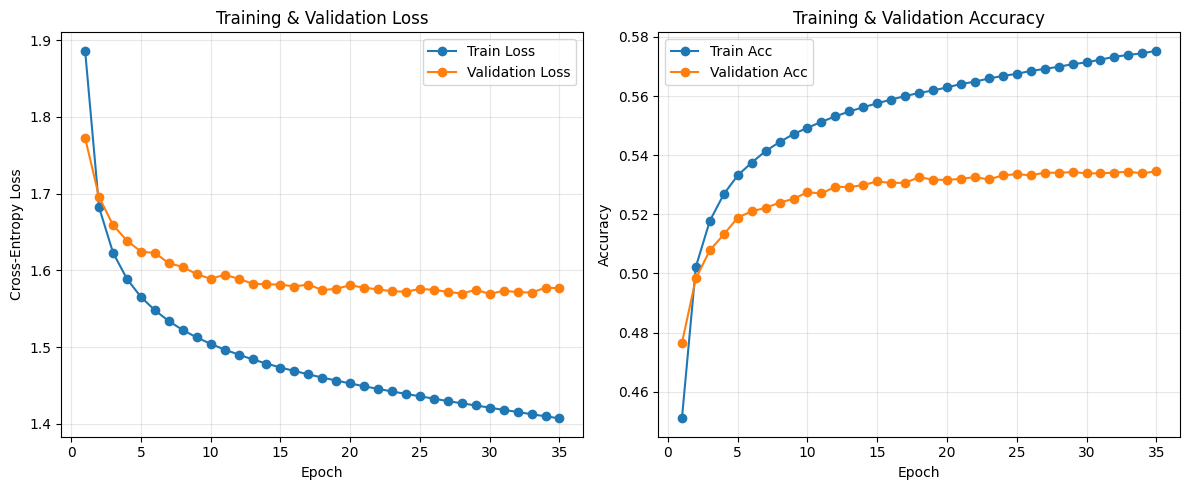

In [15]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Acc', marker='o')
plt.plot(epochs_range, val_accuracies, label='Validation Acc', marker='o')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feedforwardlm_curves.png', dpi=150)  # useful if you're pulling this into a paper/report later
plt.show()

In [16]:
######################################################################
#                    Text Generation Function
######################################################################

@torch.no_grad()
def generate_text(model, seed_text: str, char2idx: dict, idx2char: dict, context_size: int, length: int = 300, temperature: float = 0.8, top_k: int = None, device: torch.device = device,):
    """
    Generate text autoregressively from a feedforward LM.
    
    seed_text   : starting string, MUST be >= context_size characters
                  (the model only ever sees a fixed-size window, so it
                  needs a full window to make its first prediction)

    num_chars   : how many new characters to generate

    temperature : >1.0 = more random/diverse, <1.0 = more conservative/greedy,
                  1.0 = sample directly from the model's distribution

    top_k       : if set, restrict sampling to the k most likely next
                  characters at each step (filters out low-probability noise)
    """
    model.eval()

    # Unknown-character safety: fall back to a known char (e.g. space) if seed
    # contains anything outside the training vocabulary.
    unk_fallback = char2idx.get(' ', 0)
    ids = [char2idx.get(ch, unk_fallback) for ch in seed_text]

    # Left-pad with spaces if the seed is shorter than context_size
    if len(ids) < context_size:
        ids = [unk_fallback] * (context_size - len(ids)) + ids
    else:
        ids = ids[-context_size:]   # keep only the most recent context_size chars

    context = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, context_size)
    generated_chars = [idx2char[i] for i in ids]   # decode ids -> characters
    
    for _ in range(length):
        logits = model(context)                      # (1, vocab_size)
        logits = logits / max(temperature, 1e-8)      # temperature scaling

        if top_k is not None:
            top_vals, top_idx = torch.topk(logits, top_k, dim=-1)
            filtered_logits = torch.full_like(logits, float('-inf'))
            filtered_logits.scatter_(1, top_idx, top_vals)
            logits = filtered_logits

        probs = F.softmax(logits, dim=-1)             # (1, vocab_size)
        next_id = torch.multinomial(probs, num_samples=1).item()

        generated_chars.append(idx2char[next_id])

        # slide the context window forward by one character
        next_id_tensor = torch.tensor([[next_id]], device=device)
        context = torch.cat([context[:, 1:], next_id_tensor], dim=1)

    return ''.join(generated_chars)

In [17]:
######################################################################
#              Generate samples at different settings
######################################################################

seed = "the island was covered with"

print("=== Temperature 0.5 (conservative) ===")
print(generate_text(model, seed, char2idx, idx2char, Context_size, length=300, temperature=0.5))

print("\n=== Temperature 0.8, top_k=10 (balanced) ===")
print(generate_text(model, seed, char2idx, idx2char, Context_size, length=300, temperature=0.8, top_k=10))

print("\n=== Temperature 1.2 (more random) ===")
print(generate_text(model, seed, char2idx, idx2char, Context_size, length=300, temperature=1.2))

=== Temperature 0.5 (conservative) ===
             the island was covered with a slight of the could be present at the interain to the others, and they were in the peacent to the coast in the hope of the engineer and stranged a
charch of Sections, which had been and the sailor. The presest the island, in the
shook and they had a sort of the colonists had a confineer believe t

=== Temperature 0.8, top_k=10 (balanced) ===
             the island was covered with
the settlers, he shore and should be must
it is the harpoon. Through the lake and den arrivaling,
the long the forest old were and barks. The surface of the mare, that desire coilnes at
Grathes werered with it one hard who was a water-shades in the footed it also
the shore.

“It is this hair, if al

=== Temperature 1.2 (more random) ===
             the island was covered with rear he had alwasted Then ebased boured after
must arrason, phantic tifical valouncry fan hances
of this well; his fill, whosposed were lies behieving mo

![Image](images/img%2004.png)

The feedforward character-level LM learns local statistical patterns (**common words, letter sequences, suffixes**) but lacks any mechanism for modeling dependencies beyond its fixed context window, resulting in locally plausible but globally incoherent text. Lower temperatures increase fluency at the cost of diversity/repetition; higher temperatures increase novelty at the cost of well-formedness. This motivates recurrent or attention-based architectures (RNN/LSTM/Transformer) as natural extensions for improving long-range coherence.


![Image](images/img%2005.png)